# Customer Churn Business Analysis

## Capstone Project — The Developers Arena

### Project Overview

This project analyzes customer churn data to identify the major factors associated with customer attrition and translate analytical findings into actionable business recommendations.

The analysis follows an end-to-end data analytics workflow:

**Data Collection → Data Cleaning → Exploratory Data Analysis → Statistical Analysis → Customer Segmentation → Business Insights → Recommendations**

### Business Problem

Customer churn can reduce recurring revenue and increase the cost of acquiring replacement customers. The objective of this project is to identify customer segments with elevated churn risk and determine where retention efforts should be prioritized.

### Dataset

- Records: 500 customers
- Variables: 9
- Target variable: Churn

### Primary Business Questions

1. What is the overall customer churn rate?
2. Which contract types have the highest churn?
3. How does tenure relate to customer churn?
4. Are monthly charges different between retained and churned customers?
5. Which customer segment has the highest observed churn?
6. What retention strategies should the business prioritize?

### Analysis Techniques

- Exploratory Data Analysis
- Descriptive Statistics
- Correlation Analysis
- Independent t-tests
- Chi-square test
- Cramér's V effect size
- Customer risk segmentation
- Retention scenario analysis
- Revenue exposure analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "data/cleaned_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 500
Columns: 9


## Executive KPI Summary

In [3]:
total_customers = len(df)
churned_customers = df["Churn"].sum()
retained_customers = total_customers - churned_customers
churn_rate = df["Churn"].mean() * 100

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Retained Customers",
        "Churned Customers",
        "Overall Churn Rate"
    ],
    "Value": [
        total_customers,
        retained_customers,
        churned_customers,
        f"{churn_rate:.2f}%"
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,500
1,Retained Customers,447
2,Churned Customers,53
3,Overall Churn Rate,10.60%


## Key Churn Findings

The exploratory analysis identified contract type and tenure as the most important churn-related business factors in this dataset.

In [4]:
# Calculate churn rate by contract type
contract_summary = (
    df.groupby("Contract")
    .agg(
        Total_Customers=("CustomerID", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

contract_summary["Churn_Rate"] *= 100

contract_summary = contract_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

contract_summary

,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,170,35,20.588235
2,Two year,144,10,6.944444
1,One year,186,8,4.301075


### Contract Type Insight

Month-to-month customers have the highest observed churn rate at 20.59%, compared with 4.30% for one-year contracts and 6.94% for two-year contracts.

This makes month-to-month customers an important target for retention and contract-conversion initiatives.

The relationship was also statistically significant in the chi-square test, with Cramér's V of 0.2354, indicating a moderate association between contract type and churn.

### Tenure Analysis


In [5]:
tenure_bins = [0, 12, 24, 48, float("inf")]
tenure_labels = [
    "0-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49+ Months"
]

df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

tenure_summary = (
    df.groupby("TenureGroup", observed=True)
    .agg(
        Total_Customers=("CustomerID", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

tenure_summary["Churn_Rate"] *= 100

tenure_summary

,TenureGroup,Total_Customers,Churned_Customers,Churn_Rate
0,0-12 Months,84,53,63.095238
1,13-24 Months,75,0,0.000000
2,25-48 Months,171,0,0.000000
3,49+ Months,170,0,0.000000


### Tenure Insight

The first 12 months represent the most important retention period in this dataset.

Customers with 0–12 months of tenure have an observed churn rate of 63.10%, and all 53 observed churn cases occur within this tenure group.

This finding supports the use of stronger onboarding, early engagement, satisfaction checks, and proactive retention activities during the first year.

The unusually concentrated churn pattern should be validated using larger real-world data before making broad business decisions.

## Business Visualizations

The following visualizations highlight the most important customer churn patterns identified during the analysis.

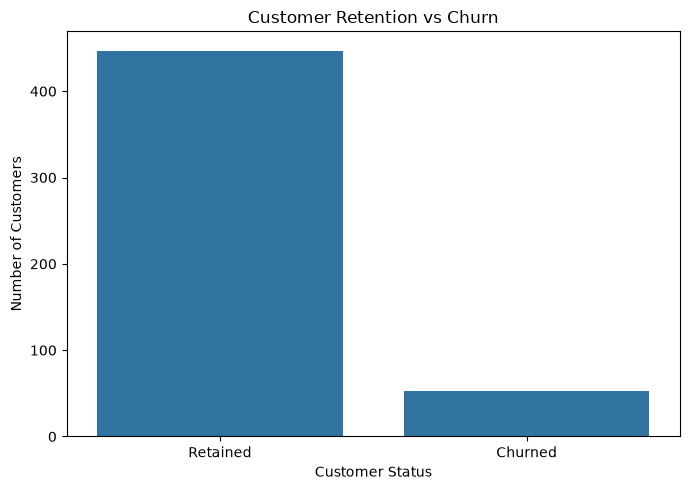

In [6]:
# Visualization 1: Overall churn distribution

churn_counts = df["Churn"].map({
    0: "Retained",
    1: "Churned"
}).value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Retention vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

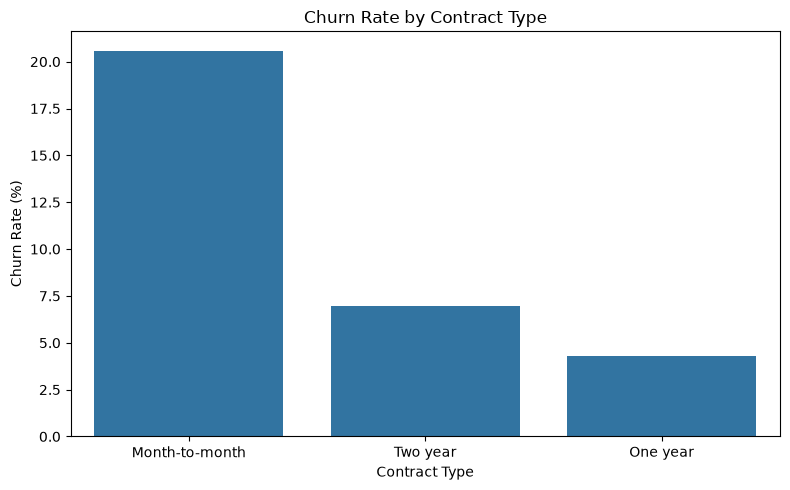

In [7]:
# Visualization 2: Churn rate by contract type

plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_summary,
    x="Contract",
    y="Churn_Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

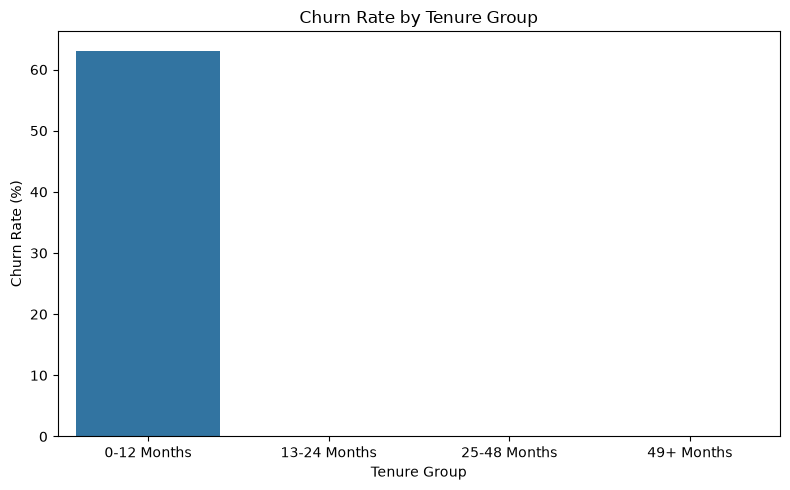

In [8]:
# Visualization 3: Churn rate by tenure group

plt.figure(figsize=(8, 5))

sns.barplot(
    data=tenure_summary,
    x="TenureGroup",
    y="Churn_Rate"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

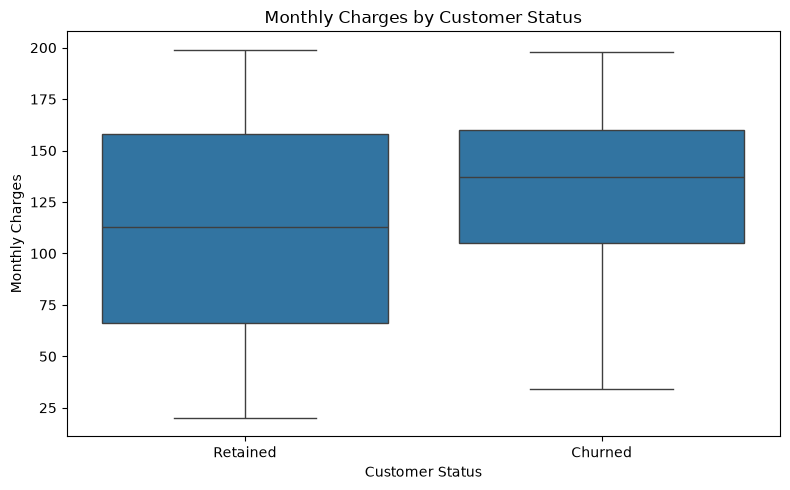

In [9]:
# Visualization 4: Monthly charges by customer status

charge_plot_df = df.copy()

charge_plot_df["Customer Status"] = charge_plot_df["Churn"].map({
    0: "Retained",
    1: "Churned"
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=charge_plot_df,
    x="Customer Status",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

In [13]:
# Create combined contract and tenure analysis

segment_analysis = (
    df.groupby(["Contract", "TenureGroup"], observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        Churned=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

segment_analysis["Churn_Rate"] *= 100

segment_analysis = segment_analysis.sort_values(
    "Churn_Rate",
    ascending=False
)

segment_analysis

,Contract,TenureGroup,Customers,Churned,Churn_Rate
0,Month-to-month,0-12 Months,35,35,100.000000
8,Two year,0-12 Months,23,10,43.478261
4,One year,0-12 Months,26,8,30.769231
1,Month-to-month,13-24 Months,23,0,0.000000
3,Month-to-month,49+ Months,66,0,0.000000
2,Month-to-month,25-48 Months,46,0,0.000000
6,One year,25-48 Months,73,0,0.000000
5,One year,13-24 Months,27,0,0.000000
7,One year,49+ Months,60,0,0.000000
9,Two year,13-24 Months,25,0,0.000000


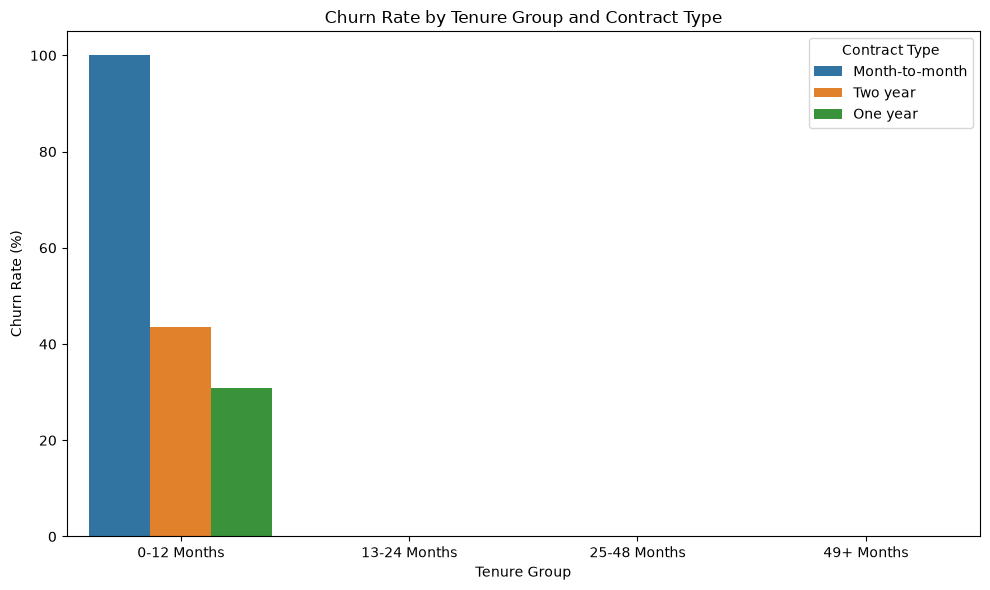

In [14]:
# Visualization 5: Combined contract and tenure analysis

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_analysis,
    x="TenureGroup",
    y="Churn_Rate",
    hue="Contract"
)

plt.title("Churn Rate by Tenure Group and Contract Type")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Contract Type")
plt.tight_layout()
plt.show()

In [ ]:
# Create risk segmentation for the capstone notebook

risk_df = df.copy()

risk_df["Early_Tenure"] = risk_df["Tenure"] <= 12
risk_df["High_Monthly_Charges"] = (
    risk_df["MonthlyCharges"] >= df["MonthlyCharges"].median()
)
risk_df["Month_to_Month"] = (
    risk_df["Contract"] == "Month-to-month"
)

risk_df["Risk_Score"] = (
    risk_df["Early_Tenure"].astype(int)
    + risk_df["High_Monthly_Charges"].astype(int)
    + risk_df["Month_to_Month"].astype(int)
)

def assign_risk_level(score):
    if score >= 3:
        return "High Risk"
    elif score == 2:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(assign_risk_level)

risk_summary = (
    risk_df.groupby("Risk_Level")
    .agg(
        Customers=("CustomerID", "count"),
        Churned=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

risk_summary["Churn_Rate"] *= 100

risk_summary = risk_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

risk_summary

,Risk_Level,Customers,Churned,Churn_Rate
0,High Risk,21,21,100.000000
2,Medium Risk,103,30,29.126214
1,Low Risk,376,2,0.531915


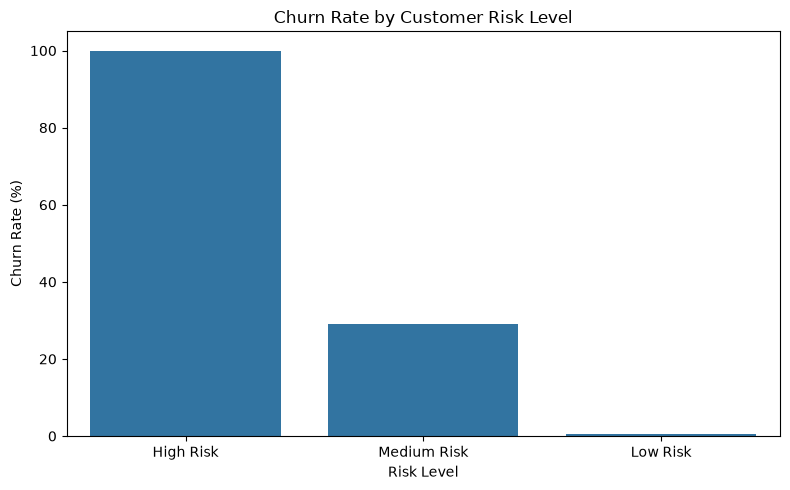

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_summary,
    x="Risk_Level",
    y="Churn_Rate"
)

plt.title("Churn Rate by Customer Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

## Statistical Validation

Statistical hypothesis testing was used to determine whether important differences and associations observed during exploratory analysis are statistically significant.

A significance level of **α = 0.05** is used.

The following tests are performed:

- Independent t-test: Monthly Charges vs Churn
- Independent t-test: Tenure vs Churn
- Chi-square test: Contract Type vs Churn
- Cramér's V: Effect size for Contract Type vs Churn

In [ ]:
# Test whether average monthly charges differ between retained and churned customers

retained_charges = df.loc[df["Churn"] == 0, "MonthlyCharges"]
churned_charges = df.loc[df["Churn"] == 1, "MonthlyCharges"]

t_stat, p_value = stats.ttest_ind(
    retained_charges,
    churned_charges,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

T-statistic: -2.6464
P-value: 0.010079


In [ ]:
# Test whether average tenure differs between retained and churned customers

retained_tenure = df.loc[df["Churn"] == 0, "Tenure"]
churned_tenure = df.loc[df["Churn"] == 1, "Tenure"]

tenure_t_stat, tenure_p_value = stats.ttest_ind(
    retained_tenure,
    churned_tenure,
    equal_var=False
)

print(f"T-statistic: {tenure_t_stat:.4f}")
print(f"P-value: {tenure_p_value:.6e}")

T-statistic: 34.5349
P-value: 8.982326e-130


In [ ]:
# Test the association between contract type and churn

contract_churn_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

chi2_stat, chi2_p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contract_churn_table
)

# Calculate Cramér's V
n = contract_churn_table.to_numpy().sum()

minimum_dimension = min(
    contract_churn_table.shape[0] - 1,
    contract_churn_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi2_stat / (n * minimum_dimension)
)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {chi2_p_value:.6e}")
print(f"Cramér's V: {cramers_v:.4f}")

Chi-square statistic: 27.7153
Degrees of freedom: 2
P-value: 9.587354e-07
Cramér's V: 0.2354


In [ ]:
statistical_summary = pd.DataFrame({
    "Analysis": [
        "Monthly Charges vs Churn",
        "Tenure vs Churn",
        "Contract Type vs Churn"
    ],
    "Test": [
        "Independent t-test",
        "Independent t-test",
        "Chi-square test"
    ],
    "P_Value": [
        p_value,
        tenure_p_value,
        chi2_p_value
    ],
    "Effect_Size": [
        abs(t_stat),
        abs(tenure_t_stat),
        cramers_v
    ],
    "Conclusion": [
        "Statistically significant",
        "Statistically significant",
        "Statistically significant"
    ]
})

statistical_summary

,Analysis,Test,P_Value,Effect_Size,Conclusion
0,Monthly Charges vs Churn,Independent t-test,1.007920e-02,2.646439,Statistically significant
1,Tenure vs Churn,Independent t-test,8.982326e-130,34.534902,Statistically significant
2,Contract Type vs Churn,Chi-square test,9.587354e-07,0.235437,Statistically significant


### Statistical Conclusion

All three hypothesis tests produced statistically significant results at the 5% significance level.

- Monthly charges differ significantly between retained and churned customers.
- Tenure differs significantly between retained and churned customers.
- Contract type is significantly associated with churn.
- The Cramér's V value of 0.2354 indicates a moderate association between contract type and churn.

Statistical significance indicates evidence of an association or difference in this dataset; it does not establish causation.

# Business Recommendations

Based on the exploratory analysis, statistical testing, segmentation, and scenario analysis, the following recommendations are proposed.

## 1. Strengthen First-Year Retention

The 0–12 month tenure group has an observed churn rate of 63.10%, with all 53 observed churn cases occurring in this group.

### Recommended Actions
- Create a structured onboarding program.
- Conduct 30/60/90-day customer check-ins.
- Provide proactive customer support during the first year.
- Identify dissatisfaction before customers decide to leave.

### KPI
**12-month customer churn rate**

---

## 2. Reduce Month-to-Month Churn

Month-to-month customers have an observed churn rate of 20.59%, considerably higher than customers on longer contracts.

### Recommended Actions
- Offer appropriate incentives for contract upgrades.
- Communicate the benefits of longer-term plans.
- Provide loyalty benefits for customers who commit to longer contracts.
- Prioritize month-to-month customers who also show other risk indicators.

### KPI
**Contract conversion rate**

---

## 3. Prioritize High-Risk Customers

The risk segmentation identified 21 high-risk customers with a 100% observed churn rate in this dataset.

### Recommended Actions
- Create a priority retention queue.
- Contact high-risk customers proactively.
- Provide personalized offers based on customer characteristics.
- Track the outcome of every retention interaction.

### KPI
**High-risk customer churn rate**

---

## 4. Review Higher Monthly Charges

Churned customers have a higher average monthly charge than retained customers, and the difference is statistically significant.

### Recommended Actions
- Review pricing and perceived value.
- Identify customers with high charges and additional churn indicators.
- Offer suitable plan optimization or service reviews.
- Monitor customer satisfaction for higher-value accounts.

### KPI
**Churn rate among high-charge customers**

---

## 5. Use Risk-Based Retention

Instead of applying the same retention strategy to every customer, the company should prioritize customers according to their observed risk characteristics.

### Suggested Priority

**High Risk → Immediate Intervention**

**Medium Risk → Targeted Engagement**

**Low Risk → Standard Customer Management**

# Business Implementation Plan

| Phase | Action | Target Customers | KPI |
|---|---|---|---|
| Phase 1 | Identify risk segments | All active customers | Risk coverage |
| Phase 2 | Launch early-tenure onboarding | 0–12 month customers | Early churn rate |
| Phase 3 | Target month-to-month customers | Month-to-month customers | Contract conversion |
| Phase 4 | Proactive retention outreach | High-risk customers | Retention rate |
| Phase 5 | Test personalized offers | High and medium risk | Campaign response |
| Phase 6 | Monitor performance | All segments | Monthly churn rate |

## Measurement Framework

The business should establish the current **10.60% churn rate** as the dataset baseline.

Performance should then be monitored using:

- Overall churn rate
- Early-tenure churn rate
- Month-to-month churn rate
- High-risk churn rate
- Contract conversion rate
- Retention campaign response rate
- Customers successfully retained

Retention campaigns should ideally be evaluated using controlled experiments or A/B testing before being scaled across the entire customer base.

# Analysis Limitations

The following limitations should be considered when interpreting the results.

1. **Dataset Size**
   - The analysis is based on 500 customers.
   - Larger datasets would provide more reliable estimates.

2. **Synthetic/Training Data Characteristics**
   - The dataset contains an unusually concentrated churn pattern, with all observed churn occurring within the first 12 months.
   - This pattern may not represent real-world customer behavior.

3. **Limited Variables**
   - The dataset does not include potentially important factors such as customer satisfaction, support interactions, complaints, service usage, acquisition channel, or customer demographics beyond senior-citizen status.

4. **Association Does Not Imply Causation**
   - Statistical tests identify relationships and differences but do not prove that a variable directly causes churn.

5. **Risk Segmentation Is Not a Predictive Model**
   - The risk score created in this project is a simple rule-based analytical framework.
   - It should not be treated as a production machine-learning churn prediction model.

6. **Revenue Exposure**
   - Monthly charge exposure is based on the available MonthlyCharges field.
   - The dataset does not specify currency, costs, discounts, profit margins, or actual realized revenue.

# Final Conclusion

This capstone project analyzed 500 customer records to identify patterns associated with customer churn and translate those findings into practical business recommendations.

The overall observed churn rate is **10.60%**.

The analysis identified three major areas of focus:

1. **Early tenure:** Customers with 0–12 months of tenure have an observed churn rate of **63.10%**.
2. **Contract type:** Month-to-month customers have an observed churn rate of **20.59%**, and contract type has a statistically significant association with churn.
3. **Monthly charges:** Churned customers have higher average monthly charges, with the difference being statistically significant.

The highest-priority segment identified was **month-to-month customers with 0–12 months of tenure**, where the observed churn rate was **100% for 35 customers**.

A risk-based retention strategy can help the business prioritize limited resources toward customers with the strongest observed risk indicators.

Overall, the project demonstrates an end-to-end business analytics workflow from data preparation through exploratory analysis, statistical validation, segmentation, scenario analysis, and actionable recommendations.

The findings should be validated against larger and more representative real-world customer data before being used for production decision-making.